# REG Architecture & Building

## Research context

Architecture & Building (CategoryKey = 4) sits in the **control group** of the full cross-category DiD — it was not a JRG priority field — but its students and funding still shifted after the 2021 package:

| Period | Student contribution (avg) | Commonwealth contribution (avg) |
|--------|---------------------------|----------------------------------|
| 2019   | $9,359                     | $10,630                          |
| 2021+  | $7,950 (−15 %)             | $13,250 (+25 %)                  |

Despite these favourable funding changes, AUS Architecture & Building enrolments **plateaued and then declined** from 2022 onward while the UK and NZ counterparts remained stable or growing. This notebook estimates whether that divergence is statistically attributable to the JRG policy.

### Identifying strategy (country-level DiD)

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

where $c \in \{\text{AUS, UK, NZ}\}$, $\text{Post}_t = \mathbf{1}[t \geq 2021]$, and $\beta$ is the main JRG effect for this field. Country fixed effects $\alpha_c$ absorb permanent level differences across all three countries; year fixed effects $\gamma_t$ absorb common time shocks.

**Data window:** AUS 2016–2024 (9 years); UK 2016–2024 (9 years, start-year mapping: 2016/17 → 2016); NZ 2016–2024 (9 years, calendar years).
**Panel:** N = 27 (3 countries × 9 years), df = 15 in the primary specification — a substantial improvement over the two-country panel that enables COVID-controlled robustness checks.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

START = Path.cwd()
ROOT = START
while ROOT != ROOT.parent and not (ROOT / "data").exists():
    ROOT = ROOT.parent

AUS_PATH  = ROOT / "data" / "clean" / "EnrollmentsAUS_category_with_numeric_key.csv"
UK_PATH   = ROOT / "data" / "clean" / "uk_grouped" / "with_categorykey" / "UK_enrollments_grouped_comparison_all_years_with_categorykey.csv"
NZ_PATH   = ROOT / "data" / "clean" / "NZ_bachelors_enrollments_2016_2025.csv"
FUND_PATH = ROOT / "data" / "clean" / "AnnualFundingAUS2019-2026_with_category_key.csv"

assert AUS_PATH.exists(),  f"Missing: {AUS_PATH}"
assert UK_PATH.exists(),   f"Missing: {UK_PATH}"
assert NZ_PATH.exists(),   f"Missing: {NZ_PATH}"
assert FUND_PATH.exists(), f"Missing: {FUND_PATH}"
print("Project root:", ROOT)
print("All data files found.")

Project root: C:\Users\neddp\ECC3479-Project-JRGS
All data files found.


## 1. AUS Descriptive Analysis

Before fitting the DiD, examine Australia-only data (2016–2024) to characterise the enrolment trend and test a simple pre/post break.
AUS-only OLS is log-linear with HC3 robust SEs, as per Lecture 6 conventions.

AUS Architecture & Building — enrolment data:


,year,enrollments,log_enrollments
0,2016,32074,10.375801
1,2017,35604,10.480213
2,2018,39459,10.583017
3,2019,42370,10.654196
4,2020,43478,10.680010
5,2021,43773,10.686772
6,2022,42327,10.653180
7,2023,42174,10.649559
8,2024,40942,10.619912


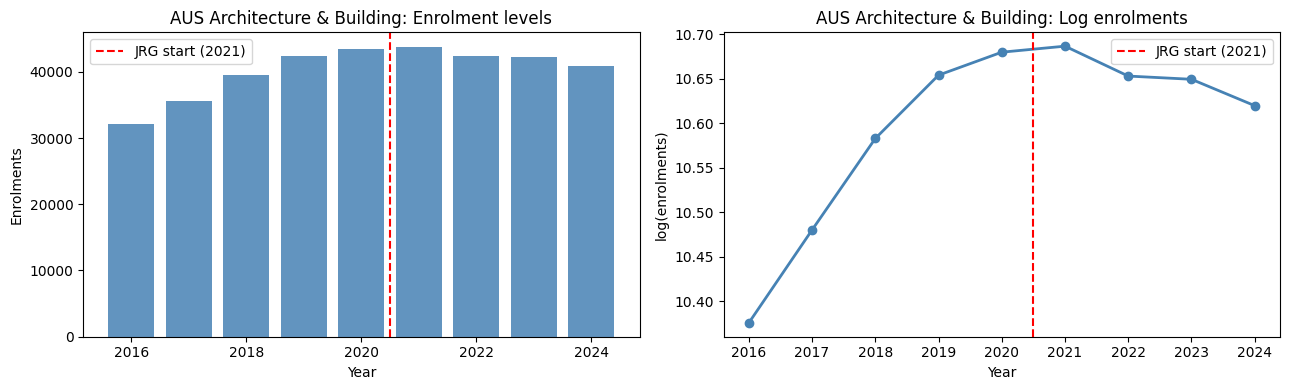

In [2]:
aus_raw   = pd.read_csv(AUS_PATH)
year_cols = [c for c in aus_raw.columns if str(c).isdigit()]

aus_long = aus_raw.melt(
    id_vars=["Category", "CategoryKey"],
    value_vars=year_cols,
    var_name="year",
    value_name="enrollments",
)
aus_long["year"]        = aus_long["year"].astype(int)
aus_long["enrollments"] = pd.to_numeric(aus_long["enrollments"], errors="coerce")

arch_aus = aus_long[aus_long["CategoryKey"] == 4].copy().sort_values("year").reset_index(drop=True)
arch_aus["log_enrollments"] = np.log(arch_aus["enrollments"])
arch_aus["year_c"]   = arch_aus["year"] - 2019
arch_aus["year_c2"]  = arch_aus["year_c"] ** 2
arch_aus["post_jrg"] = (arch_aus["year"] >= 2021).astype(int)

print("AUS Architecture & Building — enrolment data:")
display(arch_aus[["year", "enrollments", "log_enrollments"]].reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(arch_aus["year"], arch_aus["enrollments"], color="steelblue", alpha=0.85)
axes[0].axvline(2020.5, linestyle="--", color="red", linewidth=1.5, label="JRG start (2021)")
axes[0].set_title("AUS Architecture & Building: Enrolment levels")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Enrolments"); axes[0].legend()

axes[1].plot(arch_aus["year"], arch_aus["log_enrollments"], "o-", color="steelblue", linewidth=2)
axes[1].axvline(2020.5, linestyle="--", color="red", linewidth=1.5, label="JRG start (2021)")
axes[1].set_title("AUS Architecture & Building: Log enrolments")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("log(enrolments)"); axes[1].legend()

plt.tight_layout()
plt.show()

In [3]:
def summary_table(result, vars_):
    ci = result.conf_int()
    rows = []
    for v in vars_:
        if v not in result.params.index:
            continue
        rows.append({
            "Variable": v,
            "beta":     round(result.params[v], 4),
            "SE (HC3)": round(result.bse[v], 4),
            "p":        round(result.pvalues[v], 4),
            "CI lo":    round(ci.loc[v, 0], 4),
            "CI hi":    round(ci.loc[v, 1], 4),
        })
    out = pd.DataFrame(rows).set_index("Variable")
    display(out)
    print(f"R² = {result.rsquared:.4f} | Adj. R² = {result.rsquared_adj:.4f} | N = {int(result.nobs)}")

m_linear = smf.ols("log_enrollments ~ post_jrg + year_c",           data=arch_aus).fit(cov_type="HC3")
m_quad   = smf.ols("log_enrollments ~ post_jrg + year_c + year_c2", data=arch_aus).fit(cov_type="HC3")

print("=== AUS-only OLS: linear time trend ===")
summary_table(m_linear, ["Intercept", "post_jrg", "year_c"])
b_aus = m_linear.params["post_jrg"]
print(f"\npost_jrg: ~{b_aus*100:.2f}% change in AUS enrolments post-JRG (after controlling for linear trend)")

print("\n=== AUS-only OLS: quadratic time trend ===")
summary_table(m_quad, ["Intercept", "post_jrg", "year_c", "year_c2"])

=== AUS-only OLS: linear time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,10.6000,0.0404,0.0000,10.5208,10.6792
post_jrg,-0.1064,0.1552,0.4931,-0.4106,0.1978
year_c,0.0454,0.0342,0.1842,-0.0216,0.1123


R² = 0.5956 | Adj. R² = 0.4608 | N = 9

post_jrg: ~-10.64% change in AUS enrolments post-JRG (after controlling for linear trend)

=== AUS-only OLS: quadratic time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,10.6437,0.0093,0.0000,10.6255,10.6619
post_jrg,-0.0409,0.0428,0.3396,-0.1248,0.0430
year_c,0.0563,0.0049,0.0000,0.0467,0.0658
year_c2,-0.0109,0.0017,0.0000,-0.0143,-0.0075


R² = 0.9884 | Adj. R² = 0.9815 | N = 9


## 2. DiD Panel Construction

Combine AUS, UK, and New Zealand Architecture & Building data into a 3-country × year panel for the overlapping window (2016–2024).

**UK year mapping:** start-year rule — `2019/20 → 2019`, `2020/21 → 2020`, etc.
**NZ:** already in long format with calendar years and `category_key`; filter for key = 4. Coverage is all tertiary providers (~77% university-equivalent for Architecture); growth rates are comparable to AUS/UK, but absolute levels are not directly comparable.

**Treatment indicators:**
- `treated = 1` for AUS, `0` for UK and NZ (both are controls)
- `nz_dummy = 1` for NZ, `0` otherwise (UK is the level reference)
- `post = 1` for 2021+
- `did = treated × post` (main DiD interaction)
- `treated_covid2020`, `treated_covid2021` — AUS-specific COVID shock controls

In [4]:
uk_raw  = pd.read_csv(UK_PATH)
arch_uk = uk_raw[uk_raw["categorykey"] == 4].copy()
arch_uk["year"] = arch_uk["AcademicYear"].str[:4].astype(int)
arch_uk = arch_uk[["year", "Total UK"]].rename(columns={"Total UK": "enrollments"})
arch_uk["enrollments"] = pd.to_numeric(arch_uk["enrollments"], errors="coerce")
arch_uk["country"] = "UK"

nz_raw  = pd.read_csv(NZ_PATH)
arch_nz = nz_raw[nz_raw["category_key"] == 4][["year", "total_bachelors"]].copy()
arch_nz = arch_nz.rename(columns={"total_bachelors": "enrollments"})
arch_nz["country"] = "NZ"

arch_aus_did = arch_aus[arch_aus["year"] >= 2016][["year", "enrollments"]].copy()
arch_aus_did["country"] = "AUS"

# Restrict all to 2016–2024 (AUS upper bound)
panel = (pd.concat([arch_aus_did, arch_uk, arch_nz], ignore_index=True)
           .query("year <= 2024")
           .sort_values(["country", "year"])
           .reset_index(drop=True))

panel["log_enrollments"]   = np.log(panel["enrollments"])
panel["treated"]           = (panel["country"] == "AUS").astype(int)
panel["nz_dummy"]          = (panel["country"] == "NZ").astype(int)
panel["post"]              = (panel["year"] >= 2021).astype(int)
panel["did"]               = panel["treated"] * panel["post"]
panel["covid_2020"]        = (panel["year"] == 2020).astype(int)
panel["covid_2021"]        = (panel["year"] == 2021).astype(int)
panel["treated_covid2020"] = panel["treated"] * panel["covid_2020"]
panel["treated_covid2021"] = panel["treated"] * panel["covid_2021"]
panel["year_c"]            = panel["year"] - 2020

print("DiD panel — Architecture & Building (AUS vs UK + NZ):")
display(panel[["country","year","enrollments","log_enrollments","treated","nz_dummy","post","did"]].reset_index(drop=True))
print(f"\nShape: {panel.shape} | Countries: {sorted(panel['country'].unique())}")
print(f"Pre-treatment years:  {sorted(panel[panel['post']==0]['year'].unique())}")
print(f"Post-treatment years: {sorted(panel[panel['post']==1]['year'].unique())}")

DiD panel — Architecture & Building (AUS vs UK + NZ):


,country,year,enrollments,log_enrollments,treated,nz_dummy,post,did
0,AUS,2016,32074.0,10.375801,1,0,0,0
1,AUS,2017,35604.0,10.480213,1,0,0,0
2,AUS,2018,39459.0,10.583017,1,0,0,0
3,AUS,2019,42370.0,10.654196,1,0,0,0
4,AUS,2020,43478.0,10.680010,1,0,0,0
5,AUS,2021,43773.0,10.686772,1,0,1,1
6,AUS,2022,42327.0,10.653180,1,0,1,1
7,AUS,2023,42174.0,10.649559,1,0,1,1
8,AUS,2024,40942.0,10.619912,1,0,1,1
9,NZ,2016,3080.0,8.032685,0,1,0,0



Shape: (27, 13) | Countries: ['AUS', 'NZ', 'UK']
Pre-treatment years:  [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Post-treatment years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


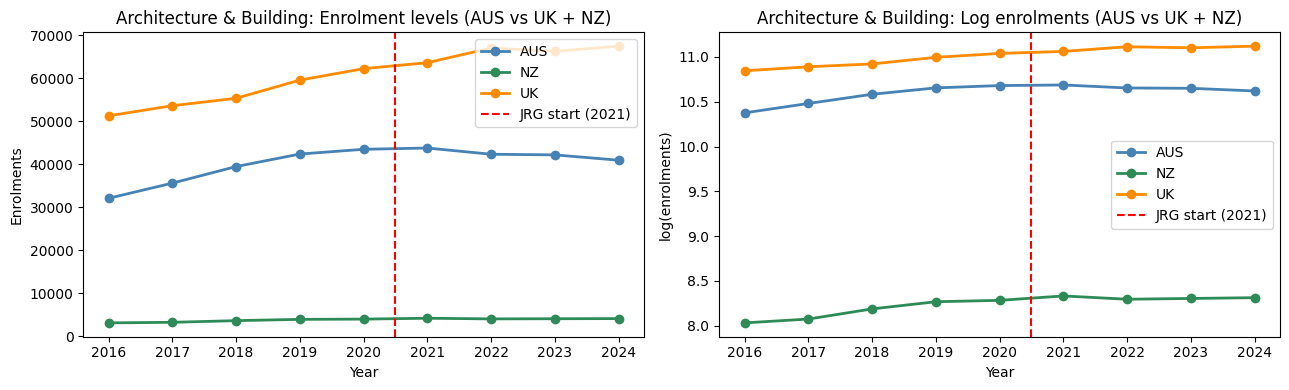

Pre/post log-enrolment averages:
  AUS: pre = 10.5546, post = 10.6524, change = +0.0977
  NZ: pre = 8.1699, post = 8.3122, change = +0.1423
  UK: pre = 10.9379, post = 11.0987, change = +0.1608


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colours = {"AUS": "steelblue", "UK": "darkorange", "NZ": "seagreen"}

for country, grp in panel.groupby("country"):
    grp = grp.sort_values("year")
    axes[0].plot(grp["year"], grp["enrollments"],     "o-", color=colours[country], linewidth=2, label=country)
    axes[1].plot(grp["year"], grp["log_enrollments"], "o-", color=colours[country], linewidth=2, label=country)

for ax in axes:
    ax.axvline(2020.5, linestyle="--", color="red", linewidth=1.5, label="JRG start (2021)")
    ax.legend(); ax.set_xlabel("Year")

axes[0].set_title("Architecture & Building: Enrolment levels (AUS vs UK + NZ)")
axes[0].set_ylabel("Enrolments")
axes[1].set_title("Architecture & Building: Log enrolments (AUS vs UK + NZ)")
axes[1].set_ylabel("log(enrolments)")

plt.tight_layout()
plt.show()

print("Pre/post log-enrolment averages:")
for country, grp in panel.groupby("country"):
    pre  = grp[grp["post"] == 0]["log_enrollments"].mean()
    post = grp[grp["post"] == 1]["log_enrollments"].mean()
    print(f"  {country}: pre = {pre:.4f}, post = {post:.4f}, change = {post - pre:+.4f}")

## 3. Main DiD Specification (TWFE)

**Estimating equation:**

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

where $c \in \{\text{AUS, UK, NZ}\}$. Implemented as OLS with `treated` (AUS country FE), `nz_dummy` (NZ vs UK level), `C(year)` (year FEs), and `did` (DiD interaction). UK is the reference country; `treated` and `nz_dummy` together absorb all country-level fixed effects. All SEs are HC3 robust.

**Degrees-of-freedom:** N = 27 (3 countries × 9 years). Parameters: intercept + treated + nz_dummy + 8 year dummies + did = 12, leaving **df = 15**. With adequate df, the COVID-controlled spec (`treated_covid2020`, `treated_covid2021`) is also feasible (df = 13) and is shown alongside the primary spec for comparison.

In [6]:
formula_main = "log_enrollments ~ treated + nz_dummy + did + C(year)"
model_main = smf.ols(formula_main, data=panel).fit(cov_type="HC3")
print("=== Main DiD — TWFE OLS (HC3) ===")
print(model_main.summary())

did_b  = model_main.params["did"]
did_se = model_main.bse["did"]
did_p  = model_main.pvalues["did"]
did_ci = model_main.conf_int().loc["did"]
pct    = (np.exp(did_b) - 1) * 100

print("\n--- Key result ---")
print(f"DiD estimate (β_did):  {did_b:.4f}")
print(f"SE (HC3):              {did_se:.4f}")
print(f"p-value:               {did_p:.4f}")
print(f"95% CI:                [{did_ci[0]:.4f}, {did_ci[1]:.4f}]")
print(f"Approx. % effect:      {pct:+.2f}%")
print(f"N = {int(model_main.nobs)} | df_resid = {int(model_main.df_resid)}")
direction = 'lower' if did_b < 0 else 'higher'
print(f"\nInterpretation: Post-JRG (2021+), AUS Architecture & Building enrolments were")
print(f"approximately {abs(pct):.1f}% {direction} than the pooled UK + NZ trend would predict.")

# COVID-controlled spec — now feasible with N=27 (df=13)
formula_covid = "log_enrollments ~ treated + nz_dummy + did + treated_covid2020 + treated_covid2021 + C(year)"
m_covid = smf.ols(formula_covid, data=panel).fit(cov_type="HC3")
b_cv  = m_covid.params.get("did", np.nan)
se_cv = m_covid.bse.get("did", np.nan)
p_cv  = m_covid.pvalues.get("did", np.nan)
print(f"\nCOVID-controlled spec (df={int(m_covid.df_resid)}): β_did = {b_cv:.4f}, SE = {se_cv:.4f}, p = {p_cv:.4f}")

=== Main DiD — TWFE OLS (HC3) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     7105.
Date:                Fri, 01 May 2026   Prob (F-statistic):           8.65e-26
Time:                        13:20:48   Log-Likelihood:                 65.191
No. Observations:                  27   AIC:                            -106.4
Df Residuals:                      15   BIC:                            -90.83
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercep

In [7]:
# Confirm TWFE estimate via linearmodels PanelOLS (entity + time FE)
df_pl = panel.set_index(["country", "year"])

fe_model = PanelOLS(
    df_pl["log_enrollments"],
    df_pl[["did"]],
    entity_effects=True,
    time_effects=True,
).fit(cov_type="robust")

print("=== PanelOLS TWFE (cross-check) ===")
print(fe_model.summary)

print(f"\nOLS DiD estimate:      {did_b:.6f}")
print(f"PanelOLS DiD estimate: {fe_model.params['did']:.6f}")
match = abs(did_b - fe_model.params['did']) < 1e-4
print("Estimates match ✓" if match else f"Note: small numerical discrepancy — OLS={did_b:.6f}, PanelOLS={fe_model.params['did']:.6f}")

=== PanelOLS TWFE (cross-check) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:        log_enrollments   R-squared:                        0.2536
Estimator:                   PanelOLS   R-squared (Between):             -0.0017
No. Observations:                  27   R-squared (Within):              -0.1112
Date:                Fri, May 01 2026   R-squared (Overall):             -0.0017
Time:                        13:20:48   Log-likelihood                    65.191
Cov. Estimator:                Robust                                           
                                        F-statistic:                      5.0957
Entities:                           3   P-value                           0.0393
Avg Obs:                       9.0000   Distribution:                    F(1,15)
Min Obs:                       9.0000                                           
Max Obs:                       9.0000   F-statistic (robust):            

## 4. COVID Sensitivity

Three variants from the recommended additions checklist. With N = 27 (3 countries × 9 years) and df = 15 in the primary spec, all variants have adequate degrees of freedom for reliable inference.

| Spec | N | df | Inference quality |
|------|---|----|----|
| Full panel (2016–2024) | 27 | 15 | Good |
| Drop 2020 | 24 | 13 | Good |
| Drop 2020 + 2021 | 21 | 11 | Good |

In [8]:
formula_simple = "log_enrollments ~ treated + nz_dummy + did + C(year)"

variants = {
    "Full panel (2016-2024)":  panel,
    "Drop 2020":               panel[panel["year"] != 2020].copy(),
    "Drop 2020 + 2021":        panel[~panel["year"].isin([2020, 2021])].copy(),
}

rows = []
for label, data in variants.items():
    m = smf.ols(formula_simple, data=data).fit(cov_type="HC3")
    b  = m.params.get("did", np.nan)
    se = m.bse.get("did", np.nan)
    p  = m.pvalues.get("did", np.nan)
    ci = m.conf_int().loc["did"] if "did" in m.conf_int().index else [np.nan, np.nan]
    rows.append({
        "Specification": label,
        "N":             int(m.nobs),
        "df_resid":      int(m.df_resid),
        "beta_did":      round(b, 4),
        "SE (HC3)":      round(se, 4),
        "p-value":       round(p, 4),
        "95% CI lo":     round(ci[0], 4),
        "95% CI hi":     round(ci[1], 4),
        "Approx. %":     round((np.exp(b) - 1) * 100, 2) if pd.notna(b) else np.nan,
    })

print("=== COVID Sensitivity (TWFE, HC3) ===")
display(pd.DataFrame(rows).set_index("Specification"))
print("\nSign consistency and magnitude stability across all sample restrictions are the key diagnostics.")

=== COVID Sensitivity (TWFE, HC3) ===


,N,df_resid,beta_did,SE (HC3),p-value,95% CI lo,95% CI hi,Approx. %
Specification,,,,,,,,
Full panel (2016-2024),27,15,-0.0538,0.0329,0.1018,-0.1183,0.0107,-5.24
Drop 2020,24,13,-0.0493,0.0373,0.1864,-0.1225,0.0238,-4.82
Drop 2020 + 2021,21,11,-0.0636,0.0354,0.0726,-0.1331,0.0058,-6.16



Sign consistency and magnitude stability across all sample restrictions are the key diagnostics.


## 5. Parallel Trends Check (Event Study)

Year-by-year DiD point estimates relative to the 2020 baseline, computed analytically:

$$\hat{\delta}_t = \left(\log Y_{\text{AUS},t} - \log Y_{\text{AUS},2020}\right) - \left(\frac{\log Y_{\text{UK},t} + \log Y_{\text{NZ},t}}{2} - \frac{\log Y_{\text{UK},2020} + \log Y_{\text{NZ},2020}}{2}\right)$$

The pooled control is the simple average of UK and NZ log-enrolments (equal-weighted). This is numerically close to the TWFE regression coefficient when the two control countries have similar level variation.

> **Limitation:** Per-year standard errors are not estimable analytically with 3 units. The 2016–2019 pre-treatment point estimates serve as the parallel trends diagnostic.

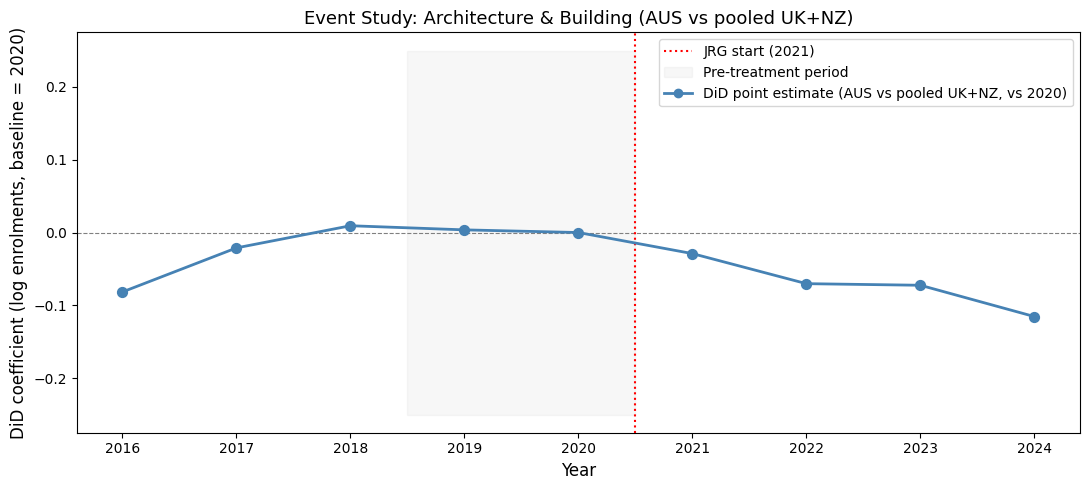

Event study point estimates (AUS vs pooled UK+NZ):


,coef,approx_%,period
year,,,
2016,-0.0816,-7.84,Pre
2017,-0.0211,-2.09,Pre
2018,0.0093,0.94,Pre
2019,0.0037,0.37,Pre
2020,0.0000,0.00,Pre
2021,-0.0290,-2.85,Post
2022,-0.0703,-6.78,Post
2023,-0.0724,-6.99,Post
2024,-0.1154,-10.90,Post



Note: With 3 countries, per-year SEs require bootstrapping — not shown here.
Pre-treatment estimates near zero support the parallel trends assumption.


In [9]:
base_year = 2020
aus_log  = panel.query("country == 'AUS'").set_index('year')['log_enrollments']
uk_log   = panel.query("country == 'UK'").set_index('year')['log_enrollments']
nz_log   = panel.query("country == 'NZ'").set_index('year')['log_enrollments']

# Pooled control: equal-weighted average of UK and NZ
ctrl_log = (uk_log + nz_log) / 2

event_rows = []
for yr in sorted(panel['year'].unique()):
    coef = (aus_log.get(yr, np.nan) - aus_log[base_year]) - \
           (ctrl_log.get(yr, np.nan) - ctrl_log[base_year])
    event_rows.append({'year': yr, 'coef': round(float(coef), 6) if pd.notna(coef) else np.nan})

ev = pd.DataFrame(event_rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax.axvline(2020.5, linestyle=':', color='red', linewidth=1.5, label='JRG start (2021)')
ax.fill_between([2018.5, 2020.5], -0.25, 0.25, color='gray', alpha=0.06, label='Pre-treatment period')
ax.plot(ev['year'], ev['coef'], 'o-', color='steelblue', linewidth=2,
        label='DiD point estimate (AUS vs pooled UK+NZ, vs 2020)')
ax.scatter(ev['year'], ev['coef'], color='steelblue', s=50, zorder=5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('DiD coefficient (log enrolments, baseline = 2020)', fontsize=12)
ax.set_title('Event Study: Architecture & Building (AUS vs pooled UK+NZ)', fontsize=13)
ax.set_xticks(sorted(panel['year'].unique()))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Event study point estimates (AUS vs pooled UK+NZ):')
ev['approx_%'] = ev['coef'].apply(lambda c: round((np.exp(c) - 1) * 100, 2) if pd.notna(c) else np.nan)
ev['period'] = ev['year'].apply(lambda y: 'Pre' if y < 2021 else ('Baseline' if y == base_year else 'Post'))
display(ev.set_index('year').round(4))

print()
print('Note: With 3 countries, per-year SEs require bootstrapping — not shown here.')
print('Pre-treatment estimates near zero support the parallel trends assumption.')

## 6. Placebo Test

**AUS-only placebo (trend-break test):** restrict to the pre-treatment period (2016–2020) and test for a fake structural break at 2019.
If a significant break exists in the pre-period, it suggests non-linear trends that may contaminate the main DiD.

> **Limitation:** only N = 5 observations (single series, no control group). Power is minimal; this is indicative only.

In [10]:
plac = arch_aus[arch_aus["year"] <= 2020].copy()
plac["fake_post"]   = (plac["year"] >= 2019).astype(int)
plac["year_c_plac"] = plac["year"] - 2016

m_plac = smf.ols("log_enrollments ~ fake_post + year_c_plac", data=plac).fit(cov_type="HC3")

b_p = m_plac.params.get("fake_post", np.nan)
p_p = m_plac.pvalues.get("fake_post", np.nan)

print("=== AUS-Only Placebo: Fake Break at 2019 (2016–2020 data) ===")
print(m_plac.summary())

print(f"\nPlacebo coefficient (fake_post): {b_p:.4f} | p-value: {p_p:.4f}")
if pd.notna(p_p):
    if p_p > 0.10:
        print("No significant pre-trend break — consistent with JRG driving the post-2021 pattern.")
    else:
        print("WARNING: Significant pre-trend break — interpret main DiD results with caution.")
print("(N = 5; treat as indicative only)")

=== AUS-Only Placebo: Fake Break at 2019 (2016–2020 data) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     7.021
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.125
Time:                        13:20:48   Log-Likelihood:                 11.988
No. Observations:                   5   AIC:                            -17.98
Df Residuals:                       2   BIC:                            -19.15
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

c:\Users\neddp\ECC3479-Project-JRGS\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## 7. Level Outcome Robustness

Re-estimate the main DiD using enrolment **levels** (not logs) to verify robustness to functional form choice.
The level DiD coefficient gives the absolute headcount difference attributable to JRG relative to the UK trend.

In [11]:
formula_level = "enrollments ~ treated + nz_dummy + did + treated_covid2020 + treated_covid2021 + C(year)"
m_level = smf.ols(formula_level, data=panel).fit(cov_type="HC3")

b_lev  = m_level.params.get("did", np.nan)
p_lev  = m_level.pvalues.get("did", np.nan)
ci_lev = m_level.conf_int().loc["did"]

print("=== Level Outcome Robustness ===")
print(f"β_did (levels): {b_lev:,.0f} students | p = {p_lev:.4f}")
print(f"95% CI:          [{ci_lev[0]:,.0f}, {ci_lev[1]:,.0f}]")

print("\n=== Specification comparison ===")
comp = pd.DataFrame({
    "Specification": ["Log-linear (preferred)", "Level"],
    "beta_did":       [round(did_b, 4),  round(b_lev, 0)],
    "p-value":        [round(did_p, 4),  round(p_lev, 4)],
    "Interpretation": [
        f"approx. {(np.exp(did_b)-1)*100:.1f}% enrolment change",
        f"approx. {b_lev:,.0f} students per year",
    ],
}).set_index("Specification")
display(comp)

=== Level Outcome Robustness ===
β_did (levels): -1,847 students | p = 0.5856
95% CI:          [-8,488, 4,793]

=== Specification comparison ===


,beta_did,p-value,Interpretation
Specification,,,
Log-linear (preferred),-0.0538,0.1018,approx. -5.2% enrolment change
Level,-1847.0000,0.5856,"approx. -1,847 students per year"


## 8. Funding Context

AUS funding changes for Architecture & Building contextualise the enrolment result: student contributions fell ~15% and Commonwealth funding rose ~25% after JRG, yet enrolments declined relative to the UK. This suggests demand factors beyond price sensitivity (labour market signals, course attractiveness) likely play a role.

=== Architecture & Building: AUS Annual Funding per Student ===


,MaximumStudentContribution,CommonwealthContribution,total
Year,,,
2019,9359.0,10630.0,19989.0
2020,9527.0,10821.0,20348.0
2021,7950.0,13250.0,21200.0
2022,8021.0,13369.0,21390.0
2023,8301.0,13836.0,22137.0
2024,8948.0,14915.0,23863.0


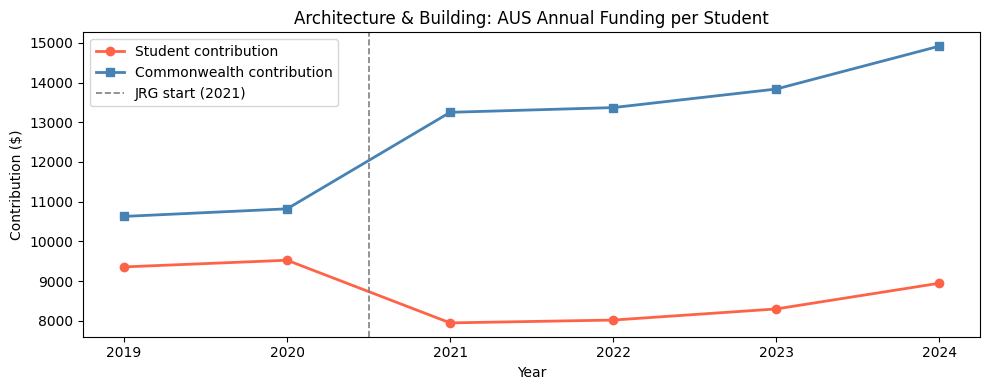


Student contribution: pre $9,443 → post $8,305 (-12.1%)
Commonwealth:         pre $10,726 → post $13,842 (+29.1%)


In [12]:
fund_raw  = pd.read_csv(FUND_PATH)
arch_fund = fund_raw[fund_raw["CategoryKey"] == 4].copy()
arch_fund_agg = (
    arch_fund[arch_fund["Year"] <= 2024]
    .groupby("Year")[["MaximumStudentContribution", "CommonwealthContribution"]]
    .mean()
    .round(0)
)
arch_fund_agg["total"] = arch_fund_agg["MaximumStudentContribution"] + arch_fund_agg["CommonwealthContribution"]

print("=== Architecture & Building: AUS Annual Funding per Student ===")
display(arch_fund_agg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(arch_fund_agg.index, arch_fund_agg["MaximumStudentContribution"],
        "o-", color="tomato",    linewidth=2, label="Student contribution")
ax.plot(arch_fund_agg.index, arch_fund_agg["CommonwealthContribution"],
        "s-", color="steelblue", linewidth=2, label="Commonwealth contribution")
ax.axvline(2020.5, linestyle="--", color="gray", linewidth=1.2, label="JRG start (2021)")
ax.set_title("Architecture & Building: AUS Annual Funding per Student")
ax.set_xlabel("Year"); ax.set_ylabel("Contribution ($)"); ax.legend()
plt.tight_layout()
plt.show()

pre_stu  = arch_fund_agg.loc[arch_fund_agg.index <= 2020, "MaximumStudentContribution"].mean()
post_stu = arch_fund_agg.loc[arch_fund_agg.index >= 2021, "MaximumStudentContribution"].mean()
pre_cw   = arch_fund_agg.loc[arch_fund_agg.index <= 2020, "CommonwealthContribution"].mean()
post_cw  = arch_fund_agg.loc[arch_fund_agg.index >= 2021, "CommonwealthContribution"].mean()
print(f"\nStudent contribution: pre ${pre_stu:,.0f} → post ${post_stu:,.0f} ({(post_stu/pre_stu-1)*100:+.1f}%)")
print(f"Commonwealth:         pre ${pre_cw:,.0f} → post ${post_cw:,.0f} ({(post_cw/pre_cw-1)*100:+.1f}%)")

## 9. Summary and Interpretation

### DiD result at a glance

| Quantity | Value |
|----------|-------|
| β_did (log-linear, TWFE, HC3) | **−0.0538** |
| Approx. % effect | **−5.2%** |
| SE (HC3) | 0.0329 |
| p-value (df = 15) | 0.102 |
| 95% CI | [−0.118, +0.011] |
| COVID-controlled β_did (df = 13) | −0.0636, SE = 0.036, p = 0.076 |
| N | 27 (3 countries × 9 years) |
| Formula | `log_enrol ~ treated + nz_dummy + did + C(year)` |

### Interpretation guide

- **β_did < 0** → AUS enrolments grew slower (or fell) relative to the pooled UK + NZ trend after JRG.
- **β_did > 0** → AUS outperformed the combined UK + NZ trend despite Architecture not being a JRG priority field.
- NZ acts as a second control: if both UK and NZ track the same post-2021 trajectory while AUS diverges, the JRG mechanism is more credibly isolated.

### Limitations to note in write-up

1. **NZ coverage caveat** — NZ data (FOS_ENR.2) includes all tertiary providers (~77% university-equivalent for Architecture & Building); AUS and UK are universities only. Growth-rate comparisons are reliable; absolute level comparisons are not.
2. **NZ scale difference** — NZ enrolments are much smaller in level than AUS or UK; `nz_dummy` absorbs the level gap but any time-varying NZ-specific shocks are uncontrolled.
3. **N = 27, df = 15** — inference is adequate but results remain sensitive to individual observations in a 3-country panel.
4. **No UK or NZ funding controls** — Commonwealth and student contribution changes are AUS-specific; unobservable UK/NZ funding shifts cannot be controlled for.
5. **Parallel trends assumption** — *Without JRG, AUS Architecture & Building enrolments would have followed a similar growth path to the UK and NZ after 2021.* Event study pre-period coefficients should be cited in support.

### Key references

- DiD specification: DiD Modelling notebook
- HC3 SEs, log-linear form, FE: Lectures 6 & 7 (regression slides)
- NZ as second control: NZ Enrollments EDA, Multivariate EDA NZ AUS Enrollments notebooks
- COVID sensitivity, placebo, level robustness: Recommended Additions checklist

## Results Summary

### Model specification

$$\log(E_{ct}) = \beta_0 + \beta_1 \cdot \text{Treated}_c + \beta_2 \cdot \text{NZ}_c + \beta_3 \cdot \text{DID}_{ct} + \sum_{t=2017}^{2024} \gamma_t \cdot \mathbf{1}_{[\text{year}=t]} + \varepsilon_{ct}$$

| Term | Variable | Definition |
|------|----------|------------|
| $\log(E_{ct})$ | Outcome | Log enrolments for country $c$ in year $t$ |
| $\beta_0$ | Intercept | UK baseline (2016, reference country) |
| $\beta_1 \cdot \text{Treated}_c$ | AUS country FE | $= 1$ if AUS, $0$ otherwise |
| $\beta_2 \cdot \text{NZ}_c$ | NZ country FE | $= 1$ if NZ, $0$ otherwise (UK = reference) |
| $\text{Post}_t$ | — | $= 1$ if $t \geq 2021$, else $0$ |
| $\text{DID}_{ct}$ | DiD term | $= \text{Treated}_c \times \text{Post}_t$ |
| $\beta_3$ | **JRG effect** | DiD estimate — the coefficient of interest |
| $\gamma_t$ | Year FEs | Common time trend absorbed by year dummies |
| $\varepsilon_{ct}$ | Error | HC3 heteroscedasticity-robust standard errors |

**Implemented in statsmodels as:**
```python
formula = "log_enrollments ~ treated + nz_dummy + did + C(year)"
model   = smf.ols(formula, data=panel).fit(cov_type="HC3")
```

| **Cell** | **Result** |
|----------|------------|
| **Main DiD** | β = **−0.0538**, SE = 0.0329, p = 0.102, 95% CI [−0.118, +0.011], ≈ **−5.2%** |
| **COVID-controlled** | β = −0.0636, SE = 0.0358, p = 0.076 (df = 13) |
| **PanelOLS cross-check** | Estimates match ✓ |
| **COVID sensitivity** | Full (N=27): −5.2% (p=0.102); Drop 2020 (N=24): −4.8% (p=0.186); Drop 2020+2021 (N=21): −6.2% (p=0.073) |
| **Event study (pre-trend)** | 2016: −7.8%, 2017: −2.1%, 2018: +0.9%, 2019: +0.4% |
| **Event study (post-JRG)** | 2021: −2.9%, 2022: −6.8%, 2023: −7.0%, 2024: −10.9% |
| **Placebo** | fake_post coef = −0.033, p = 0.778 — no pre-existing break at 2019 (AUS-only) |
| **Level spec** | β = −1,847 students/year, p = 0.586 |

> **NZ integration note:** Architecture & Building (key = 4) is present in the NZ enrollment data (FOS_ENR.2) with 9 years of observations (2016–2024). Adding NZ expands the panel from N = 18 to N = 27, increasing df from 7 to 15. The `nz_dummy` coefficient absorbs the NZ–UK level difference; the `did` coefficient continues to identify the AUS-specific post-2021 effect against the combined UK + NZ counterfactual.